# SR3 RV Lab — Framework 5: the meeting lattice (curve-implied vs listed digitals)

**RV class: D / B — what the options know that the curve does not.**

This is the one framework where the comparison is genuinely between the two
markets rather than between an option surface and itself.

1. From the **futures strip alone**, least-squares solve a per-meeting jump for
   every FOMC date, using the exact day-weight matrix (SR3 settles on the
   day-weighted average of its reference quarter, so a meeting inside the
   quarter counts fractionally — a Dec-9 hike moves a Dec contract by roughly a
   sixth of its size, not by 25bp).
2. Turn each jump into the FedWatch two-point lattice (`mantissa_probs`), couple
   the meetings **independently**, and day-weight them into each contract's
   settlement. That gives `P_null(rate >= K)` — a distribution that reproduces
   the futures market by construction and contains no option information.
3. Compare with the **listed** `P(rate >= K)` read off the traded vertical.

The gap is the price of everything the null throws away: marginal shape, tails,
non-25bp outcomes, intermeeting risk and meeting-to-meeting coupling. It is a
risk premium, so its *level* is not a trade — its **deviation from its own
history** is what gets tested here, and the trade is the listed vertical.

In [1]:
CONFIG = dict(
    offsets_bp=(-25.0, 0.0, 25.0),   # strikes relative to each contract's forward
    strike_tol=0.10,
    min_oi=100,
    min_tte=0.15,
    contracts_per_leg=100,
    cost_bp=1.5,                      # 2 option legs -> a vertical is cheap
    mas=(1, 5, 10),
    zscore_windows=(60, 120),
    entry_zs=(1.0, 1.5, 2.0),
    exits=("t5", "t10", "z0"),
    directions=("fade", "momentum"),
)
CONFIG

{'offsets_bp': (-25.0, 0.0, 25.0),
 'strike_tol': 0.1,
 'min_oi': 100,
 'min_tte': 0.15,
 'contracts_per_leg': 100,
 'cost_bp': 1.5,
 'mas': (1, 5, 10),
 'zscore_windows': (60, 120),
 'entry_zs': (1.0, 1.5, 2.0),
 'exits': ('t5', 't10', 'z0'),
 'directions': ('fade', 'momentum')}

In [2]:
import datetime
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sfr_rv_lab_common import LabConfig, load_lab, run_framework
from RVUtils.SFRRVLab import (
    FOMC_DATES, Leg, Structure, add_event_distance, constant_maturity_slots,
    quarterly_sort_key, vertical_digital,
)
from RVUtils.SFRRVLab.lattice import (
    day_weight_matrix, meeting_null_distribution, null_prob_ge,
    solve_meeting_jumps,
)
from RVUtils.SFRRVLab.signals import digital_legs
from MDP.STIRFutures._sofr_option_contracts import quarterly_reference_window

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

lab = load_lab()
quotes, contracts = lab["quotes"], lab["contracts"]
# `contracts` already carries tte from the panel builder; only the slot is new
contracts = contracts.merge(
    constant_maturity_slots(contracts)[["as_of", "symbol", "cm_slot"]],
    on=["as_of", "symbol"], how="left")

WINDOWS = {s: quarterly_reference_window(s)
           for s in sorted(contracts["symbol"].unique(), key=quarterly_sort_key)}
for s, w in WINDOWS.items():
    print(f"  {s}: reference quarter {w[0]} .. {w[1]}")

  SFRZ26: reference quarter 2026-12-16 .. 2027-03-17
  SFRH27: reference quarter 2027-03-17 .. 2027-06-16
  SFRM27: reference quarter 2027-06-16 .. 2027-09-15
  SFRU27: reference quarter 2027-09-15 .. 2027-12-15
  SFRZ27: reference quarter 2027-12-15 .. 2028-03-15
  SFRH28: reference quarter 2028-03-15 .. 2028-06-21
  SFRM28: reference quarter 2028-06-21 .. 2028-09-20


## Step 1-2 — the curve-only null, per date

The base rate is the front contract's own forward: with the front quarter
largely already fixed, it anchors the level the meeting jumps move away from.

In [3]:
fwd = contracts.set_index(["as_of", "symbol"])["forward_rate"]
fwd_px = contracts.set_index(["as_of", "symbol"])["forward_price"]
QDAY = {k: v for k, v in quotes.groupby(["as_of", "symbol"], sort=False)}

rows = []
for ts, day in contracts.groupby("as_of"):
    day = day[day["tte"] >= CONFIG["min_tte"]].sort_values("expiry_date")
    syms = [s for s in day["symbol"] if s in WINDOWS]
    if len(syms) < 3:
        continue
    wins = [WINDOWS[s] for s in syms]
    d0 = ts.date()
    meetings = [m for m in FOMC_DATES if d0 < m <= max(w[1] for w in wins)]
    if not meetings:
        continue
    W = day_weight_matrix(wins, meetings)
    fwd_bp = np.array([float(fwd[(ts, s)]) * 100.0 for s in syms])
    base_bp = float(fwd_bp[0])
    jumps = solve_meeting_jumps(fwd_bp, W, base_bp)
    for i, sym in enumerate(syms):
        off, p = meeting_null_distribution(jumps, W[i], merge_bp=0.5)
        g = QDAY.get((ts, sym))
        if g is None:
            continue
        if CONFIG["min_oi"] > 0:
            g = g[g["oi"] >= CONFIG["min_oi"]]
        f_rate = float(fwd[(ts, sym)])
        f_px = float(fwd_px[(ts, sym)])
        for o in CONFIG["offsets_bp"]:
            k_rate = f_rate + o / 100.0
            d = vertical_digital(g, k_rate, tol=CONFIG["strike_tol"],
                                 forward_price=f_px)
            if d is None:
                continue
            p_null = null_prob_ge(off, p, base_bp, k_rate * 100.0)
            rows.append({
                "as_of": ts, "symbol": sym, "offset_bp": o,
                "key": f"{sym}@{o:+.0f}",
                "p_listed": d["prob"], "p_null": p_null,
                "signal": d["prob"] - p_null,
                "k_lo": d["k_lo"], "k_hi": d["k_hi"], "right": d["right"],
                "n_meetings": len(meetings), "gate": True,
            })
lat = pd.DataFrame(rows)
print(f"\nlattice panel (raw): {len(lat)} rows")

# Hygiene: a normalised vertical is a probability. Values outside [0, 1] mean a
# stale settle or a bracket that straddles the OTM boundary with mismatched
# widths — not information. Drop them and say how many.
if len(lat):
    bad = ~lat["p_listed"].between(-0.02, 1.02)
    print(f"dropping {int(bad.sum())} rows ({bad.mean():.2%}) whose listed "
          f"vertical implies a probability outside [0, 1]")
    lat = lat[~bad].copy()
print(f"lattice panel: {len(lat)} rows, {lat['key'].nunique() if len(lat) else 0} keys")
if len(lat):
    lat = add_event_distance(lat)
    print(lat.groupby("offset_bp")[["p_listed", "p_null", "signal"]]
          .describe().round(3).to_string())


lattice panel (raw): 3950 rows
dropping 3 rows (0.08%) whose listed vertical implies a probability outside [0, 1]
lattice panel: 3947 rows, 21 keys
          p_listed                                              p_null                                                   signal                                                 
             count   mean    std   min   25%   50%   75%   max   count   mean    std    min    25%    50%    75%    max   count   mean    std    min    25%    50%    75%    max
offset_bp                                                                                                                                                                       
-25.0       1288.0  0.652  0.051  0.54  0.62  0.64  0.68  0.84  1288.0  0.958  0.060  0.665  0.935  0.988  0.999  1.000  1288.0 -0.305  0.055 -0.440 -0.349 -0.317 -0.277 -0.085
 0.0        1320.0  0.510  0.058  0.32  0.48  0.50  0.56  0.68  1320.0  0.595  0.312  0.033  0.319  0.606  0.929  1.000  1320.0 -0.085  0.304 -

### The gap is a premium, not an arbitrage

If the options systematically price more tail than the two-point lattice, the
gap has a persistent sign. That level is the price of the information the null
discards; only the deviation from it is a candidate trade.

mean gap (listed - null) by strike offset:
             mean     std  count
offset_bp                       
-25.0     -0.3054  0.0555   1288
 0.0      -0.0850  0.3038   1320
 25.0      0.3231  0.0782   1339

How much of the gap's VARIATION is the options side rather than the null? If the null is near-degenerate at a strike, the 'gap' signal is just the listed digital wearing a different name:
           p_listed  p_null
offset_bp                  
-25.0        0.0507  0.0602
 0.0         0.0577  0.3118
 25.0        0.0471  0.0567


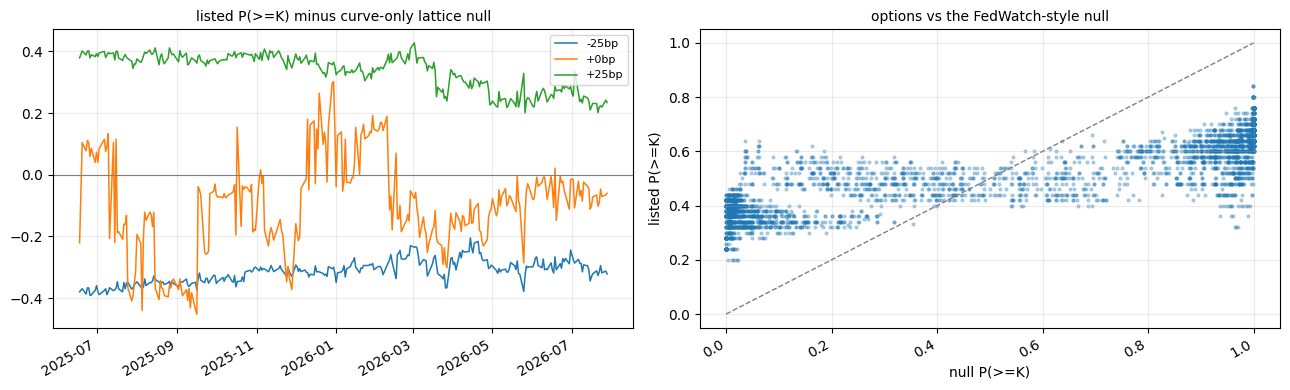

In [4]:
if len(lat):
    print("mean gap (listed - null) by strike offset:")
    print(lat.groupby("offset_bp")["signal"].agg(["mean", "std", "count"])
          .round(4).to_string())
    print("\nHow much of the gap's VARIATION is the options side rather than the "
          "null? If the null is near-degenerate at a strike, the 'gap' signal is "
          "just the listed digital wearing a different name:")
    print(lat.groupby("offset_bp")[["p_listed", "p_null"]].std().round(4).to_string())
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for o, sub in lat.groupby("offset_bp"):
        s = sub.groupby("as_of")["signal"].mean()
        axes[0].plot(s.index, s.to_numpy(), lw=1.1, label=f"{o:+.0f}bp")
    axes[0].axhline(0, color="grey", lw=0.8)
    axes[0].legend(fontsize=8)
    axes[0].set_title("listed P(>=K) minus curve-only lattice null", fontsize=10)
    axes[0].grid(alpha=0.25)
    axes[1].scatter(lat["p_null"], lat["p_listed"], s=4, alpha=0.3)
    axes[1].plot([0, 1], [0, 1], color="grey", ls="--", lw=1)
    axes[1].set_xlabel("null P(>=K)")
    axes[1].set_ylabel("listed P(>=K)")
    axes[1].set_title("options vs the FedWatch-style null", fontsize=10)
    axes[1].grid(alpha=0.25)
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

## Step 3 — trade the deviation, as the listed vertical

  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 5. Meeting lattice (listed vs FedWatch null) — grid ===
  108 configs | median -154.44bp | IQR [-406.82, -2.25] | 24% net-positive | best +639.23bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
 momentum   1            120               1.0         t5       315     0.286       2.029       639.226     1598065.25   1.544   -174.992
 momentum   5            120               2.0         t5        95     0.316       4.159       395.094      987734.75   1.251   -157.619
 momentum   5            120               1.5        t10       122     0.369       3.114       379.946      949864.50   0.791   -261.072
 momentum  10            120               1.5        t10       115     0.339       2.506       288.164      720411.25   0.478   -381.352
 momentum  10            120               1.0         t5       264     0.269       1.0

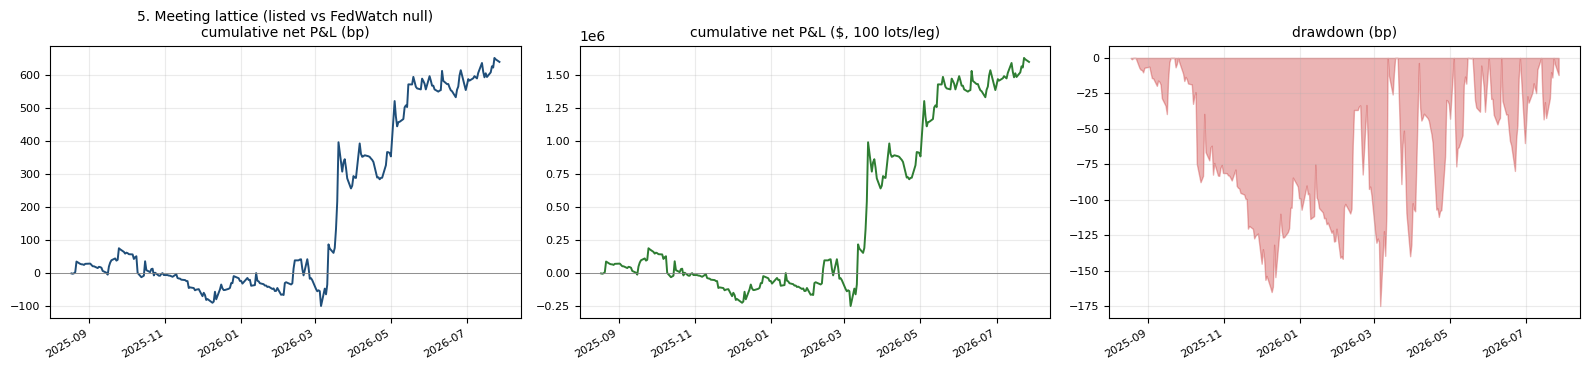


TRADE LOG (first rows)
       key  dir          structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp   net_bp    net_usd  stale_frac  pkg_contracts exit_reason
 SFRZ26@+0    1  digital SFRZ26@+0  2025-08-14 2025-08-15 2025-08-22     5  1.146   35.3072      1.5  33.8072   84517.95       0.128           16.0        time
SFRZ26@-25    1 digital SFRZ26@-25  2025-08-14 2025-08-15 2025-08-22     5  1.576    1.0395      1.5  -0.4605   -1151.15       0.000           16.0        time
SFRM27@+25    1 digital SFRM27@+25  2025-08-14 2025-08-15 2025-08-22     5  1.279   -1.0470      1.5  -2.5470   -6367.42       0.394           16.0        time
SFRZ26@+25    1 digital SFRZ26@+25  2025-08-15 2025-08-18 2025-08-25     5  1.300    0.3799      1.5  -1.1201   -2800.19       0.390           16.0        time
 SFRM27@+0   -1  digital SFRM27@+0  2025-08-15 2025-08-18 2025-08-25     5 -2.108   -0.2188      1.5  -1.7188   -4296.96       0.480           16.0        time
SFRH27@-25    1 

exit  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp  avg_hold_days
  z0       283     0.223      -0.588      -166.505     -416261.50  -0.320   -287.396          6.544
half       286     0.248       0.995       284.540      711349.75   0.476   -370.916          6.154
  t5       315     0.286       2.029       639.226     1598065.25   1.544   -174.992          4.933
 t10       203     0.330       0.318        64.484      161209.50   0.136   -432.618          9.867
 t20       125     0.296      -0.473       -59.173     -147931.75  -0.117   -378.581         19.120

MARKS x LAG


signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0       359         769.927       231.427   0.369     0.251
       listed    1       315        1111.726       639.226   1.544     0.286
same-bar (lag 0) gross inflation: -44.4%

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 315      1111.726       3.529     0.508     2779315.25
           0.5 315       954.226       3.029     0.422     2385565.25
           1.0 315       796.726       2.529     0.346     1991815.25
           1.5 315       639.226       2.029     0.286     1598065.25
           2.5 315       324.226       1.029     0.197      810565.25
           4.0 315      -148.274      -0.471     0.137     -370684.75

5. Meeting lattice (listed vs FedWatch null) — median config (not selected)  |  momentum|ma10|w60|z1.5|z0|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 16 contracts -

In [5]:
LAT_IDX = lat.set_index(["key", "as_of"]).sort_index() if len(lat) else None


def builder(key, exec_date, direction):
    try:
        r = LAT_IDX.loc[(key, exec_date)]
    except (KeyError, AttributeError):
        return None
    if isinstance(r, pd.DataFrame):
        r = r.iloc[0]
    sym = key.split("@")[0]
    return Structure(digital_legs(sym, float(r["k_lo"]), float(r["k_hi"]),
                                  str(r["right"]), weight=1.0),
                     label=f"digital {key}")


BASE = LabConfig(lag=1, round_trip_cost_bp=CONFIG["cost_bp"],
                 contracts_per_leg=CONFIG["contracts_per_leg"],
                 delta_hedge="daily", future_leg_bp=0.25)
GRID = {"direction": list(CONFIG["directions"]), "ma": list(CONFIG["mas"]),
        "zscore_window": list(CONFIG["zscore_windows"]),
        "entry_min_zscore": list(CONFIG["entry_zs"]),
        "exit_style": list(CONFIG["exits"])}
PARAMS = ["direction", "ma", "zscore_window", "entry_min_zscore", "exit_style"]

if len(lat):
    out = run_framework(
        "5. Meeting lattice (listed vs FedWatch null)", signals=lat,
        book=lab["book"], builder=builder, base=BASE, grid_spec=GRID,
        params=PARAMS, cls="D/B",
        note="listed vertical, delta-hedged daily; null solved from the strip")

## FOMC-window variant

The null is a *meeting* model, so if it carries information at all it should
carry it around meetings.

eligible bars: 16.0%



=== 5b. Meeting lattice (FOMC window) — grid ===
  16 configs | median -97.50bp | IQR [-403.52, +240.27] | 50% net-positive | best +385.49bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
 momentum   1               1.0        t10        78     0.244       4.942       385.488      963720.50   1.197   -266.080
 momentum   1               1.5         t5        38     0.316       8.328       316.447      791118.00   2.471    -69.146
 momentum   1               1.5        t10        38     0.289       7.701       292.640      731599.50   0.977   -242.430
 momentum   5               1.5         t5        36     0.361       7.466       268.783      671958.25   2.290    -78.189
 momentum   1               1.0         t5        78     0.218       2.959       230.766      576915.00   1.708   -164.324
 momentum   5               1.0        t10        

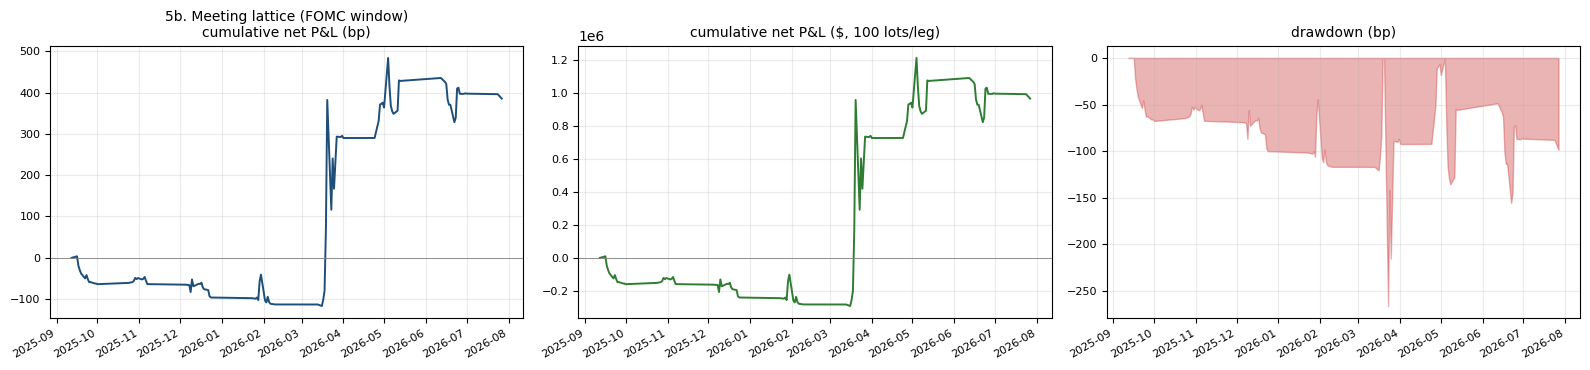


EXIT COMPARISON


exit  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp  avg_hold_days
  z0        84     0.262       1.677       140.888      352219.50   0.323   -492.856          6.905
half        86     0.267       2.716       233.552      583881.25   0.649   -277.640          6.267
  t5        78     0.218       2.959       230.766      576915.00   1.708   -164.324          4.538
 t10        78     0.244       4.942       385.488      963720.50   1.197   -266.080          8.962
 t20        78     0.321       2.908       226.799      566998.50   0.439   -475.803         17.808

MARKS x LAG
signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0        78         659.439       542.439   1.640     0.282
       listed    1        78         502.488       385.488   1.197     0.244
same-bar (lag 0) gross inflation: 23.8%

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_n


  LEAGUE ROW  5b. Meeting lattice (FOMC window) / best-config: SELECTION-ARTIFACT  (taker +307.49bp, maker +502.49bp, DSR p=0.041)

  LEAGUE ROW  5b. Meeting lattice (FOMC window) / median-config: DEAD  (taker -353.93bp, maker -191.43bp, DSR p=0.000)


In [6]:
if len(lat):
    ev = lat.copy()
    ev["eligible"] = ev["days_to_fomc"].between(-7, -1)
    print(f"eligible bars: {ev['eligible'].mean():.1%}")
    out_ev = run_framework(
        "5b. Meeting lattice (FOMC window)", signals=ev, book=lab["book"],
        builder=builder, base=BASE,
        grid_spec={"direction": list(CONFIG["directions"]), "ma": [1, 5],
                   "entry_min_zscore": [1.0, 1.5], "exit_style": ["t5", "t10"]},
        params=["direction", "ma", "entry_min_zscore", "exit_style"], cls="D/B",
        note="entries limited to 7 business days pre-FOMC", show_trades=0)